In [ ]:
import operator
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict, Literal
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

In [60]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(
        description="Detailed, constructive feedback on the tweet's tone, clarity, and engagement value."
    )
    evaluation: Literal["approve", "needs_improvement"] = Field(
        description="Choose 'approve' if ready to publish as-is; otherwise choose 'needs_improvement'."
    )

In [61]:
load_dotenv()
llm = init_chat_model(model="gemini-3.5-flash-lite", model_provider="google_genai")
evaluation_llm = llm.with_structured_output(EvaluationSchema)

In [62]:
class TweetState(TypedDict):
    topic : str
    post : str
    evaluation : Literal["approve", "needs_improvement"]
    feedback : str
    iteration : int
    max_iteration : int
    tweet_history : Annotated[list[str], operator.add]
    feedback_history : Annotated[list[str], operator.add]

In [63]:
def generate_message(state : TweetState):
    prompt = state["topic"]
    message = [
        SystemMessage(
            content=(
                "You are a witty, satirical X (formerly Twitter) creator known for punchy, "
                "relatable humor and dry observations. Write naturally in modern social media cadence: "
                "short sentences, clever punchlines, and hyper-specific situational details. "
                "Avoid corporate speak, cringey setups, and hashtag spam."
            )
        ),
        HumanMessage(content=prompt),
    ]

    post = llm.invoke(message).content
    return {"post" : post}

def evaluation_generator(state : TweetState):
    system_prompt = (
        "You are an expert social media editor and comedy critic evaluating viral posts on X (Twitter).\n"
        "Your goal is to ensure the draft achieves maximum comedic impact, crisp timing, and high relatability.\n\n"
        "Evaluation Rubric:\n"
        "1. Length: Must be strictly under 280 characters.\n"
        "2. Hook & Cadence: Strong setup, no fluff, punchy delivery, reads like a human thought.\n"
        "3. Comedic Value: Uses vivid hyperbole, irony, or relatable specificity (not generic clichés).\n"
        "4. Tone: Natural internet cadence. Zero cringe, corporate speak, or hashtag spam.\n\n"
        "Instructions:\n"
        "- If the post meets all criteria and cannot be meaningfully improved, set evaluation to 'approve'.\n"
        "- If the post is too long, flat, cliché, or missing a punchline, set evaluation to 'needs_improvement'.\n"
        "- In 'feedback', provide 1-2 specific, actionable instructions on what to cut, heighten, or rewrite."
    )

    user_prompt = (
        f"<topic>\n{state['topic']}\n</topic>\n\n"
        f"<current_draft>\n{state['post']}\n</current_draft>\n\n"
        "Evaluate the draft against the rubric and provide your structured assessment."
    )

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = evaluation_llm.invoke(messages)

    return {
        "feedback": response.feedback,
        "evaluation": response.evaluation,
        "feedback_history" : [response.feedback]
    }

def condition_check(state: TweetState):
    if state["evaluation"] == "approved" or state["iteration"] >= state["max_iteration"]:
        return "approved"
    else: 
        return "needs_improvement"
    
def optimizer(state : TweetState):
    system_prompt = (
        "You are an elite ghostwriter and social media comedy writer specializing in punchy, viral posts.\n"
        "Your job is to rewrite drafts based on editorial feedback to make them sharper, shorter, and funnier.\n\n"
        "Optimization Guidelines:\n"
        "- Cut ruthlessly: Remove filler words, unnecessary preambles, and weak descriptors.\n"
        "- Elevate the rhythm: Ensure the final sentence/word lands the strongest comedic punch.\n"
        "- Stay under 280 characters.\n"
        "- Maintain the core humor while directly fixing every issue raised in the critique.\n"
        "- Output ONLY the final revised tweet. Do NOT include quotation marks, explanations, or introductory text."
    )

    user_prompt = (
        f"<topic>\n{state['topic']}\n</topic>\n\n"
        f"<current_draft>\n{state['post']}\n</current_draft>\n\n"
        f"<editorial_critique>\n{state['feedback']}\n</editorial_critique>\n\n"
        "Rewrite the post incorporating the critique above. Return ONLY the new post text."
    )

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]
    response = llm.invoke(messages).content
    iteration = state["iteration"] + 1
    
    return {"post" : response, "iteration" : iteration, "tweet_history" : [response]}

In [64]:
graph = StateGraph(TweetState)

graph.add_node('generate_message', generate_message)
graph.add_node('evaluation_generator', evaluation_generator)
graph.add_node('optimizer', optimizer)

graph.add_edge(START, "generate_message")
graph.add_edge("generate_message", "evaluation_generator")
graph.add_conditional_edges("evaluation_generator", condition_check, {"approved":END, "needs_improvement": "optimizer"})
graph.add_edge("optimizer", "evaluation_generator")

workflow = graph.compile()

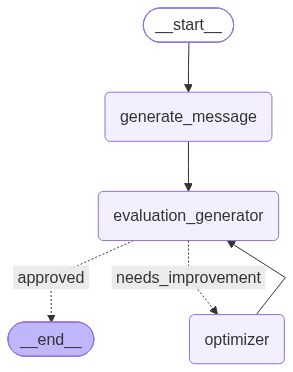

In [68]:
workflow

In [66]:
initial_state: TweetState = {
    "topic": (
        "Write a short, viral tweet about the legendary traffic jams in Dhaka. "
        "Include relatable local elements (e.g., CNGs, rickshaws, signal wait times, or growing old in Mohakhali/Farmgate). "
        "Keep it under 280 characters with at most 1 subtle hashtag or none at all."
    ),
    "post": "",
    "evaluation": "needs_improvement",
    "feedback": "",
    "iteration": 0,
    "max_iteration": 2,
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'Write a short, viral tweet about the legendary traffic jams in Dhaka. Include relatable local elements (e.g., CNGs, rickshaws, signal wait times, or growing old in Mohakhali/Farmgate). Keep it under 280 characters with at most 1 subtle hashtag or none at all.', 'post': [{'type': 'text', 'text': 'Left Mohakhali for Farmgate in 2018. Just celebrated my 40th in a CNG. The driver started a family in the backseat, my rickshaw puller is training for the senior Olympics, and we’ve moved 3 inches. Engine is off, grandfather is dead, vibe is immaculate.', 'extras': {'signature': 'El4KXAERTTIPXi/BTd+Lo2OwQ7J+WAlpQzJcEr6gxBPhnXsnKupiV0Q4NwER/blinMqmS+BrWkUrRbgLxdiQeWDK0k9kljJiwA4J9j9N1gon9+ghCGxKiTpa8U516ws8'}}], 'evaluation': 'approve', 'feedback': 'The draft hits the exact right tone with great hyperbole and local specifics. The pacing is fast and funny. Approved.', 'iteration': 2, 'max_iteration': 2, 'tweet_history': [[{'type': 'text', 'text': 'Left Mohakhali for Farmgate in 2018. J

In [67]:
print(final_state["post"][0]['text'])

Left Mohakhali for Farmgate in 2018. Just celebrated my 40th in a CNG. The driver started a family in the backseat, my rickshaw puller is training for the senior Olympics, and we’ve moved 3 inches. Engine is off, grandfather is dead, vibe is immaculate.
